# Лабораторная работа 7

## Анализ и прогнозирование временного ряда.
### Цель лабораторной работы: изучение основных методов анализа и прогнозирование временных рядов.

# Датасет:
Текстовое описание набора данных
Набор данных по исследованию качества воздуха - https://archive.ics.uci.edu/dataset/360/air+quality

Набор содержит почасовые данные, полученные от комбинированного газоанализатора, установленного в итальянском городе вблизи автомобильной магистрали. Данные записывались с Марта 2004 по февраль 2005 (один год).

Датасет состоит из 2-х файлов одинаковых данных в формате .csv и .xlsx

Каждый файл содержит следующие колонки:

Date дата в формате ДЕНЬ-МЕСЯЦ-ГОД Набор данных содержит данные с интервалом измерения в один час.
Time время в формате ЧАСЫ:МИНУТЫ:СЕКУНДЫ.
CO(GT) концентрация СО mg/m^3
PT08.S1(CO) концентрация СО mg/m^3 усредненная за час
NMHC(GT) максимальная концентрация паров гидрокарбонатов усредненная за час microg/m^3
C6H6(GT) максимальная концентрация паров бензина усредненная за час microg/m^3
PT08.S2(NMHC) концентрация паров гидрокарбонатов усредненная за час microg/m^3
NOx(GT) максимальная концентрация оксидов азота усредненная за час microg/m^3
PT08.S3(NOx) концентрация оксидов азота усредненная за час microg/m^3
NO2(GT) максимальная концентрация двуокиси азота усредненная за час microg/m^3
PT08.S4(NO2) концентрация двуокиси азота усредненная за час microg/m^3
PT08.S5(O3) концентрация озона усредненная за час microg/m^3
T температура в градусах Цельсия
RH относительная влажность в %.
AH абсолютная влажность в %.
Category категория качества воздуха - Good/Bad


In [46]:
from scipy.stats import mode
from time import time
import os
import random
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from io import StringIO 
from IPython.display import Image
import graphviz 
import pydotplus
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from IPython.display import display, HTML
from itertools import chain
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPClassifier
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")
import warnings
warnings.filterwarnings('ignore')

In [47]:
# 
data = pd.read_csv('air+quality/2.csv', sep=";", index_col=0, parse_dates=True)
data = data.drop(columns=['Unnamed: 16'])

In [48]:
# Первые 5 строк датасета
data.head()

,Time,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH,Category
Date,,,,,,,,,,,,,,,
10.03.2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268,13.6,48.9,0.7578,Bad
10.03.2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972,13.3,47.7,0.7255,Bad
10.03.2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074,11.9,54.0,0.7502,Bad
10.03.2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203,11.0,60.0,0.7867,Bad
10.03.2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110,11.2,59.6,0.7888,Good


## Для моделирования выбираем температуру и влажность за июль 2004 года

In [49]:
# Фильтр по июлю 2004
td = data['01.07.2004':'30.07.2004']
td = td[['T','RH']]
td.head()

,T,RH
Date,,
01.07.2004,27.1,47.4
01.07.2004,26.2,49.4
01.07.2004,26.9,49.3
01.07.2004,26.3,50.8
01.07.2004,24.9,54.6


In [50]:
td.describe()

,T,RH
count,720.000000,720.000000
mean,29.365417,32.891944
std,6.163172,12.645540
min,16.200000,9.600000
25%,24.600000,21.475000
50%,28.000000,33.000000
75%,34.200000,43.225000
max,44.600000,69.300000


## Визуализация

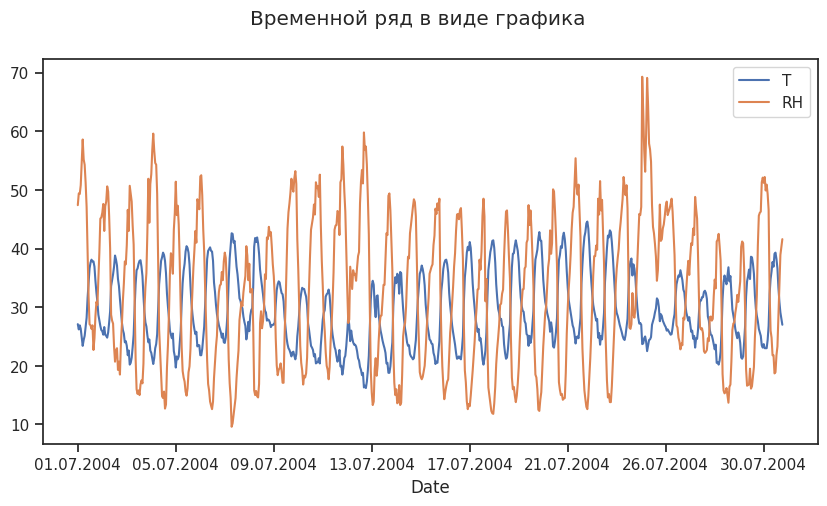

In [51]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде графика')
td.plot(ax=ax, legend=True)
plt.show()


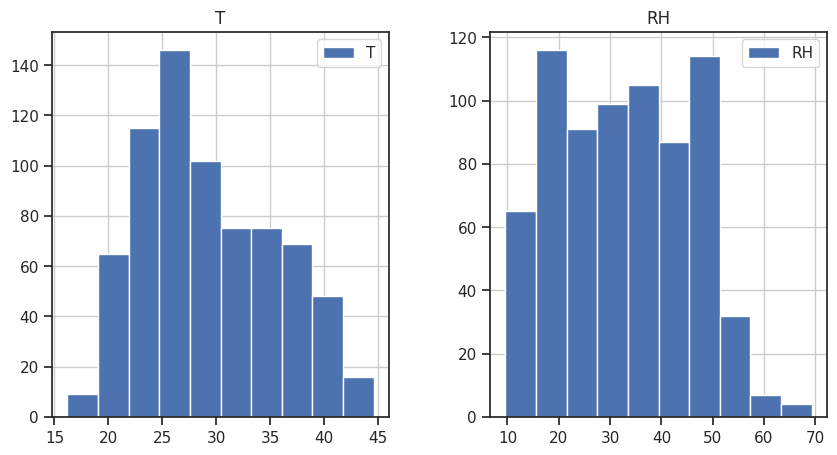

In [52]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
td.hist(ax=ax, legend=True)
plt.show()

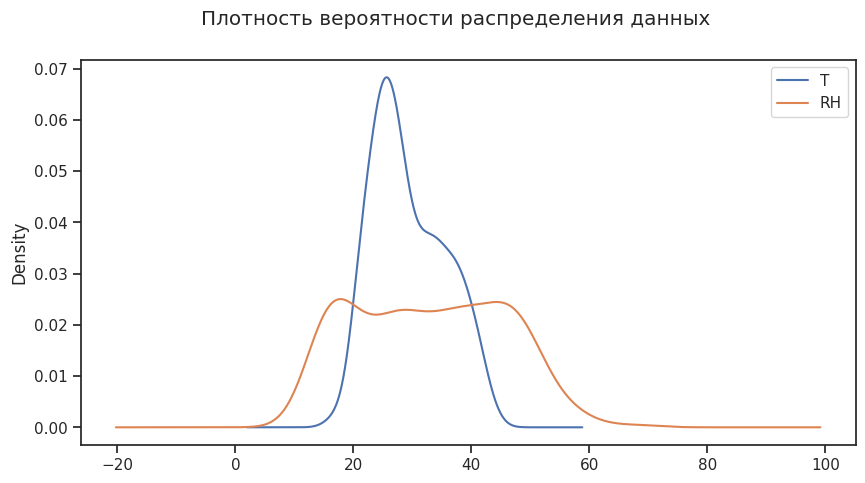

In [53]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Плотность вероятности распределения данных')
td.plot(ax=ax, kind='kde', legend=True)
plt.show()


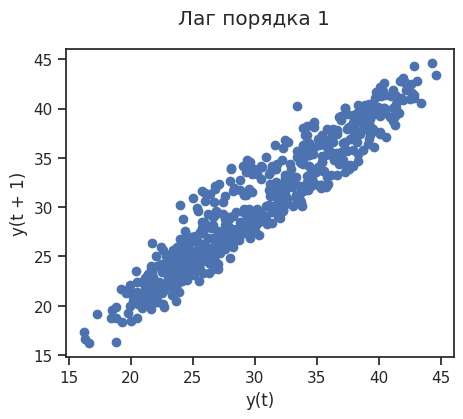

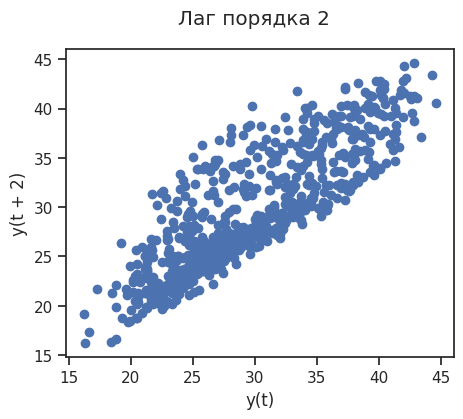

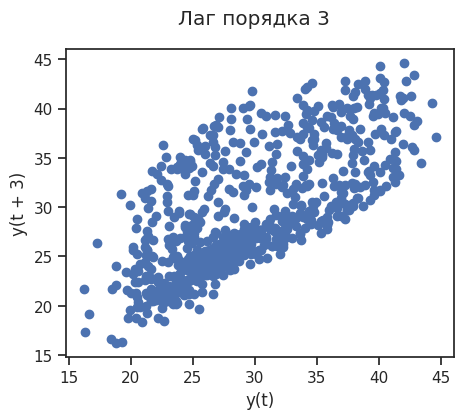

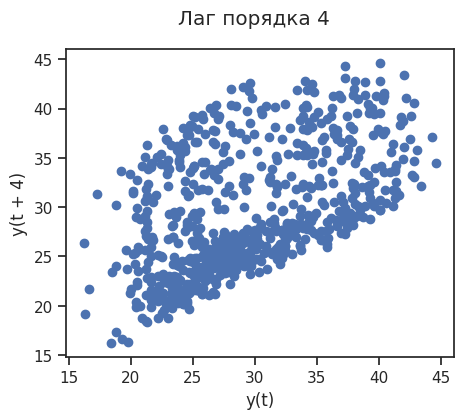

In [54]:
# LAG plots
for i in range(1, 5):
    fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(5,4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(td['T'], lag=i, ax=ax)
    plt.show()

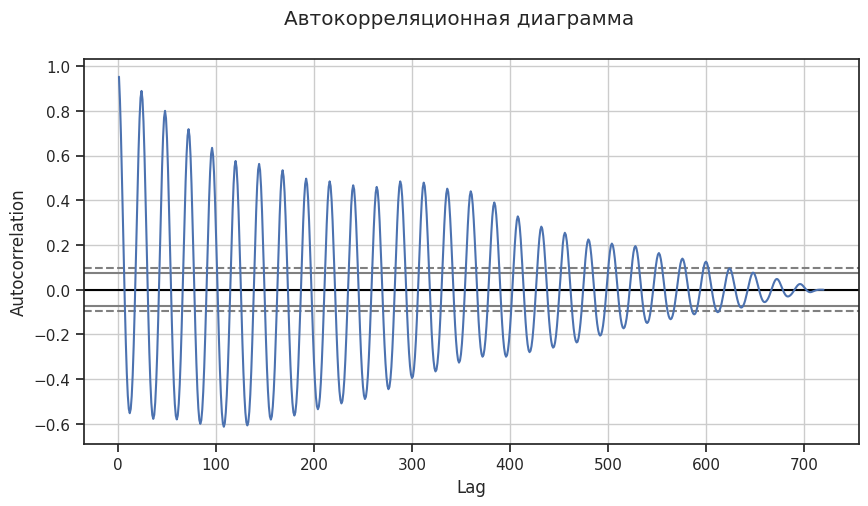

In [55]:
# По оси Y откладывается ковариация 
# https://stats.stackexchange.com/questions/357300/what-does-pandas-autocorrelation-graph-show
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(td['T'], ax=ax)
plt.show()


## Декомпозиция временного ряда с помощью библиотеки statsmodels

In [56]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Аддитивная модель
def plot_decompose(data=td, model='add'):
    result_add = seasonal_decompose(data, period=24, model = 'add')
    fig = result_add.plot()
    fig.set_size_inches((10, 8))
    # Перерисовка
    fig.tight_layout()
    plt.show()


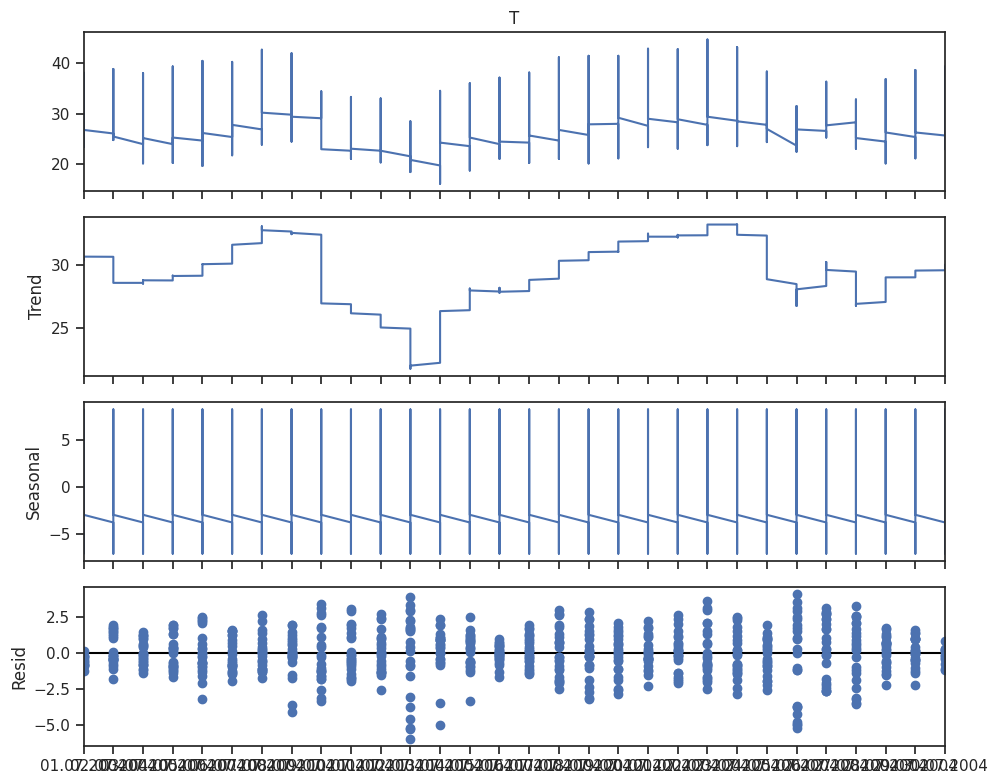

In [57]:
plot_decompose(data=td['T'], model='add')

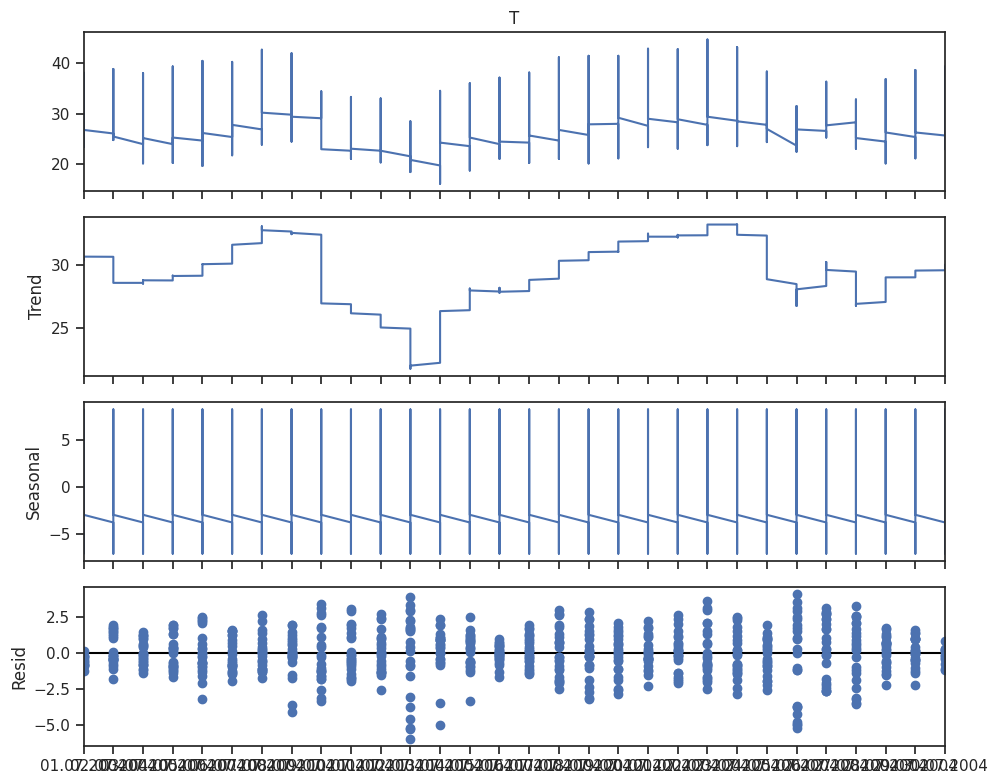

In [58]:
plot_decompose(data=td['T'], model='mul')

## Скользящая средняя

In [59]:
td2 = td.copy()
td2 = td2.drop(columns=['RH'])

In [60]:
# Простое скользящее среднее (SMA)
td2['SMA_10'] = td2['T'].rolling(10, min_periods=1).mean()
td2['SMA_20'] = td2['T'].rolling(20, min_periods=1).mean()


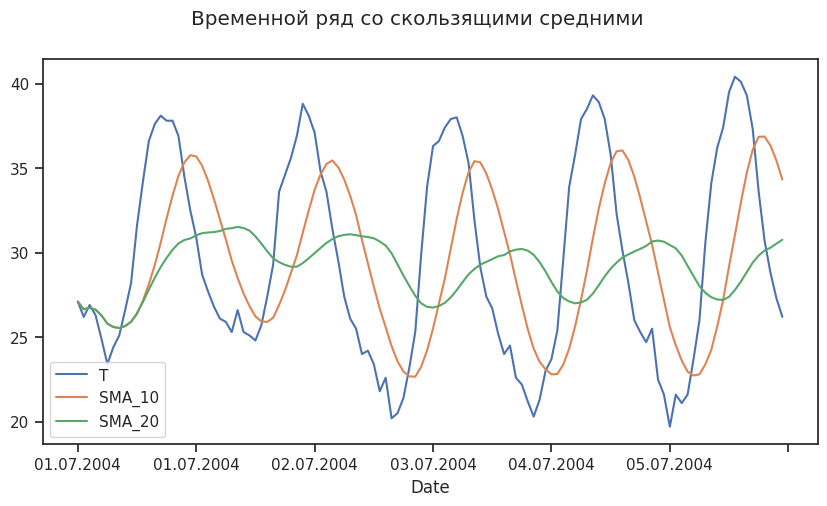

In [61]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд со скользящими средними')
td2[:120].plot(ax=ax, legend=True)
plt.show()

## Прогнозирование временного ряда авторегрессионными методами (ARIMA)

In [62]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [63]:
# Целочисленная метка шкалы времени 
xnum = list(range(td2.shape[0]))
# Разделение выборки на обучающую и тестовую
Y = td2['T'].values
train_size = int(len(Y) * 0.7)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]


In [64]:
# Параметры модели (p,d,q) 
arima_order = (6,1,0)
# Формирование предсказаний
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Вычисление метрики RMSE
error_arima = mean_squared_error(test, predictions_arima)

In [65]:
# Формирование предсказаний
predictions_es = list()
for t in range(len(test)):
    model_es = ExponentialSmoothing(history_es)
    model_es_fit = model_es.fit()
    yhat_es = model_es_fit.forecast()[0]
    predictions_es.append(yhat_es)
    history_es.append(test[t])
# Вычисление метрики RMSE
error_es = mean_squared_error(test, predictions_es)


In [66]:
# Ошибка прогноза
np.mean(Y), error_arima, error_es

(np.float64(29.365416666666665), 2.0910757356003, 3.2264055855469236)

In [67]:
# Записываем предсказания в DataFrame
td2['predictions_ARIMA'] = (train_size * [np.nan]) + list(predictions_arima)
td2['predictions_HWES'] = (train_size * [np.nan]) + list(predictions_es)


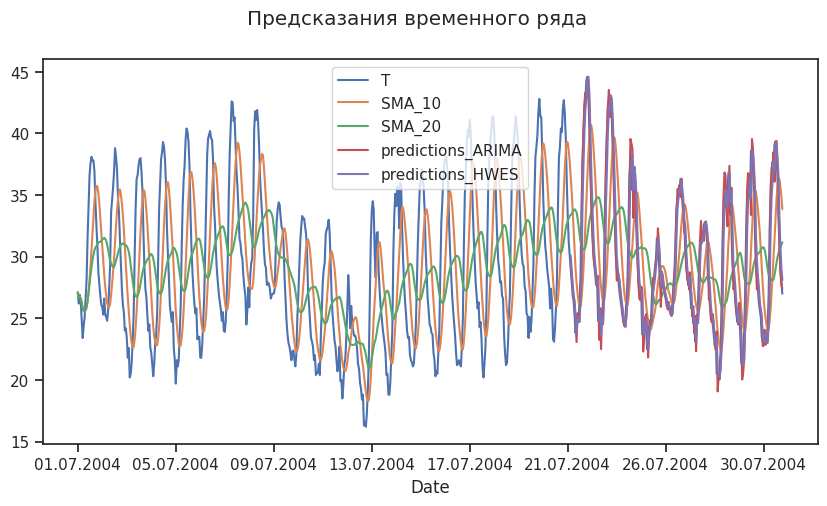

In [68]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда')
td2.plot(ax=ax, legend=True)
plt.show()

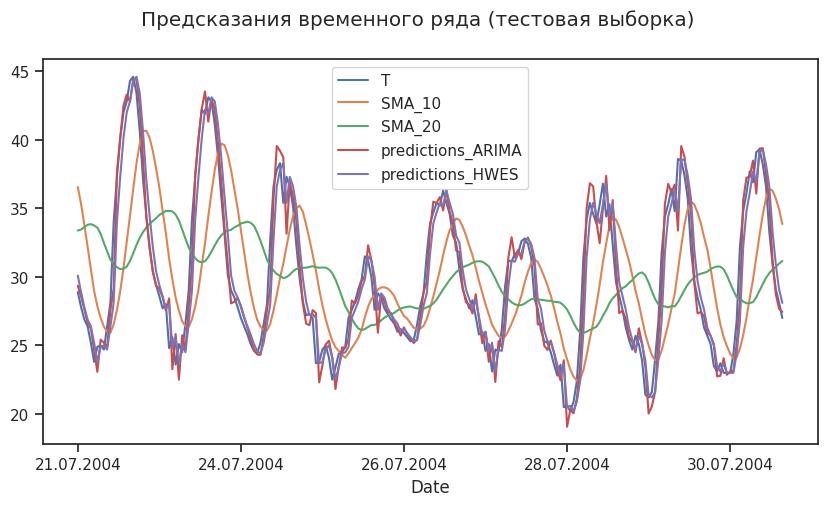

In [69]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
td2[train_size:].plot(ax=ax, legend=True)
plt.show()

## Прогнозирование временного ряда методом символьной регресии

In [70]:
from gplearn.genetic import SymbolicRegressor

In [71]:
function_set = ['add', 'sub', 'mul', 'div', 'sin']
est_gp = SymbolicRegressor(population_size=500, metric='mse',
                               generations=70, stopping_criteria=0.01,
                               init_depth=(4, 10), verbose=1, function_set=function_set,
                               const_range=(-100, 100), random_state=0)

In [72]:
est_gp.fit(np.array(xnum_train).reshape(-1, 1), train.reshape(-1, 1))

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0   263.65      8.00226e+61      766          831.444              N/A     52.27s
   1   154.20      8.18445e+13       35          416.202              N/A     25.84s
   2   401.20      3.75508e+11       45          53.0545              N/A     38.36s
   3   162.97      3.72388e+20       47          44.0749              N/A     20.09s
   4    43.68      1.29861e+14      102          44.0617              N/A     10.68s
   5    53.53      2.81775e+15       63          42.7538              N/A     11.25s
   6    66.92      2.65652e+14      109          42.7253              N/A     11.99s
   7    62.46      2.84341e+15       54          42.4457              N/A     11.68s
   8    73.04      2.31193e+15       54          42.4341              N/A  

,population_size,500
,generations,70
,tournament_size,20
,stopping_criteria,0.01
,const_range,"(-100, ...)"
,init_depth,"(4, ...)"
,init_method,'half and half'
,function_set,"['add', 'sub', ...]"
,metric,'mse'
,parsimony_coefficient,0.001
,p_crossover,0.9


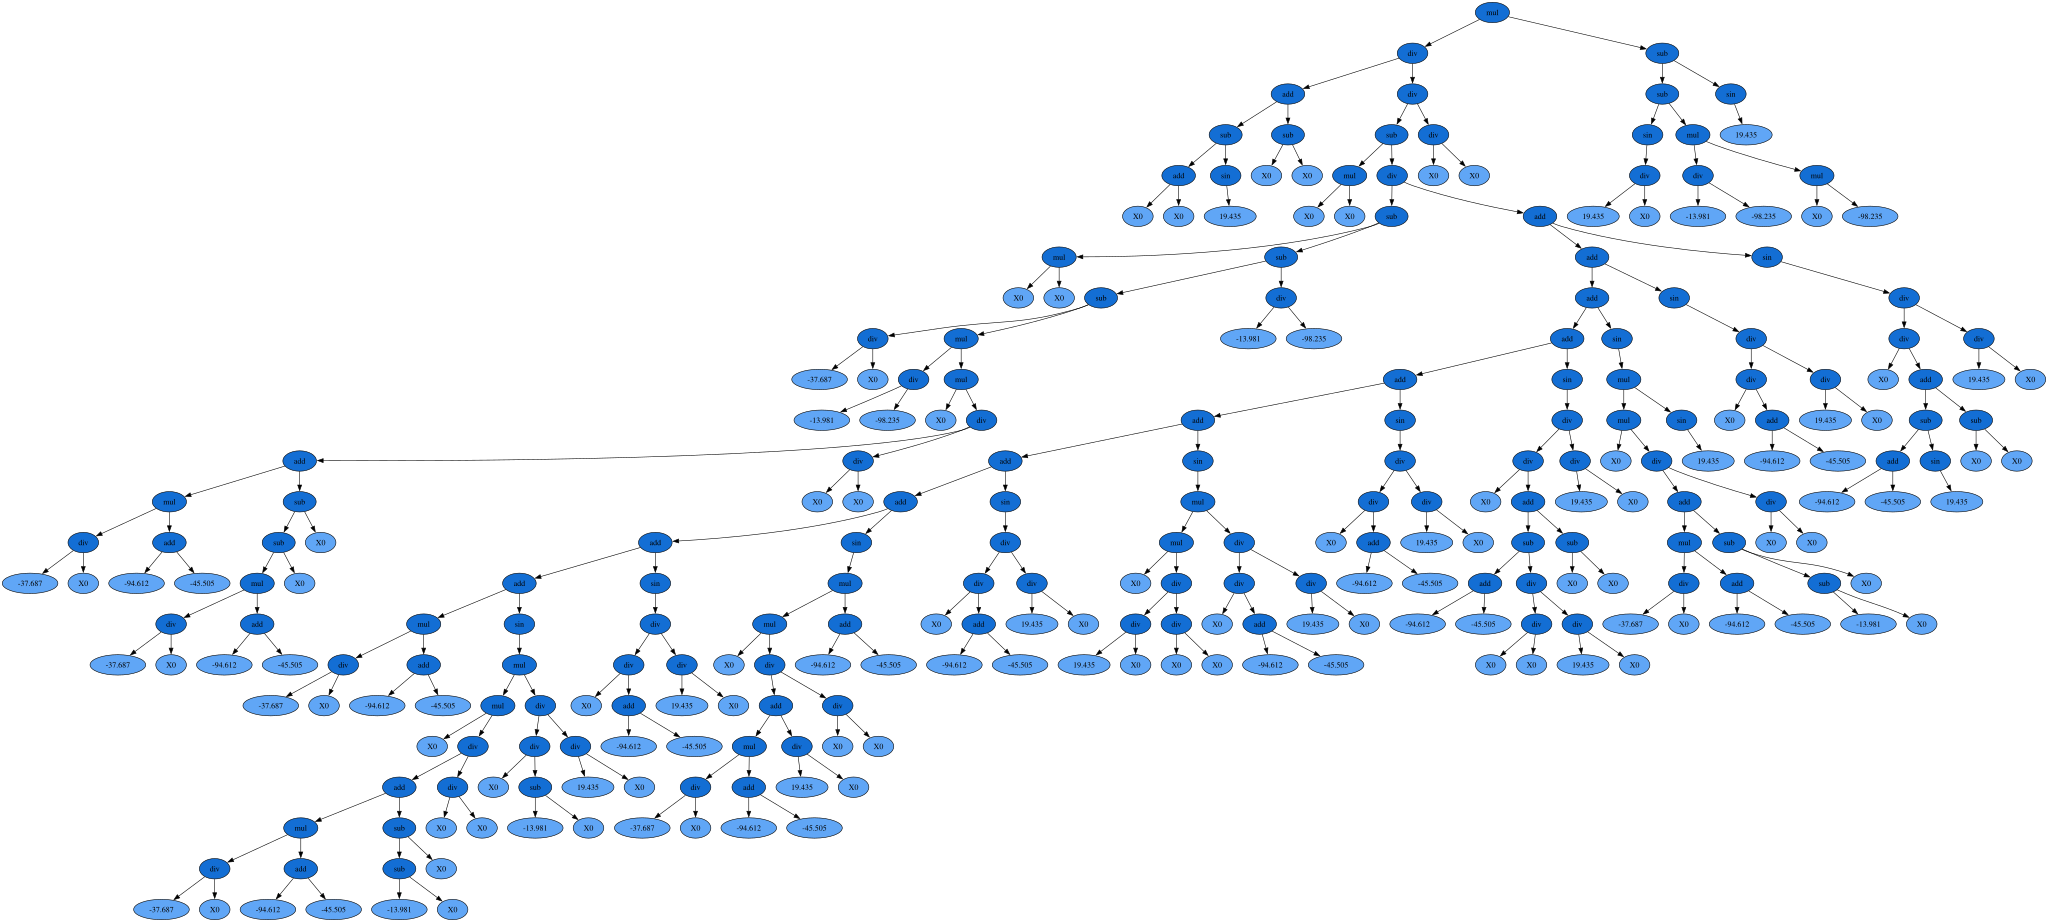

In [73]:
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph

In [74]:
# Предсказания
y_gp = est_gp.predict(np.array(xnum_test).reshape(-1, 1))
y_gp[:10]

array([29.5081184 , 29.31875114, 29.37794715, 29.4879863 , 30.05998494,
       30.43199298, 31.10883222, 33.1172896 , 31.24628076, 30.77702733])

In [75]:
# Записываем предсказания в DataFrame
td2['predictions_GPLEARN'] = (train_size * [np.nan]) + list(y_gp)


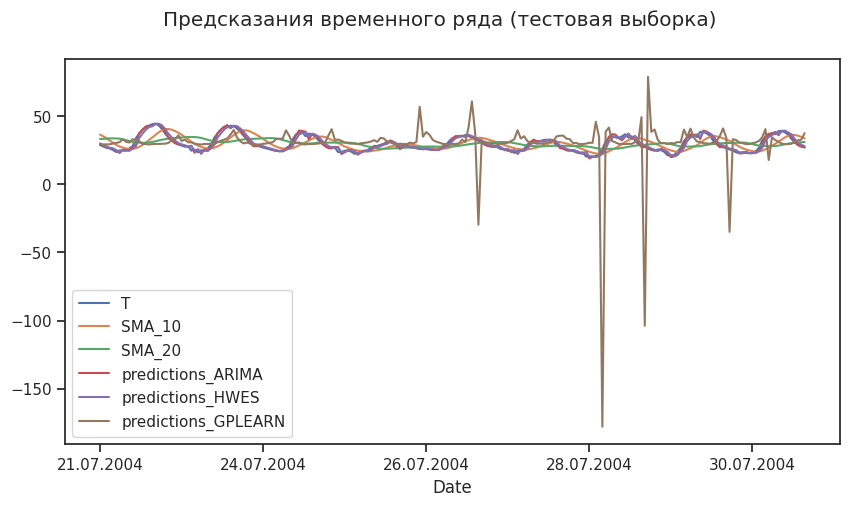

In [76]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
td2[train_size:].plot(ax=ax, legend=True)
plt.show()